# A3 – Inteligência Artificial
## Comitê de Classificadores: Previsão de Churn em Telecomunicações

**Disciplina:** Inteligência Artificial  
**Universidade:** Universidade São Judas Tadeu  
**Prazo de entrega:** 09/06/2026

---

### Integrantes do Grupo
- César Melo Ribeiro
- Julia Leite Venancio
- Kaue Lucas da Silva
- Vinicius Iandoli Diogo

---

## 1. Introdução

O **churn** (cancelamento de clientes) é um dos problemas mais críticos para empresas de telecomunicações. Perder um cliente custa, em média, 5 a 25 vezes mais do que reter um já existente. Prever quais clientes têm maior probabilidade de cancelar permite que a empresa adote ações preventivas — como ofertas personalizadas ou melhorias no serviço — antes que a perda ocorra.

Este projeto aplica técnicas de **aprendizado de máquina supervisionado** para construir um **comitê de classificadores (ensemble)**, combinando os algoritmos KNN, Naive Bayes, Árvore de Decisão e SVM. A abordagem em comitê tem como objetivo superar o desempenho individual de cada modelo, aproveitando a diversidade entre eles.

**Pipeline do projeto:**
1. Escolha e justificativa da base de dados
2. Definição do problema e da variável target
3. Pré-processamento e análise exploratória (EDA)
4. Treinamento e avaliação individual dos classificadores
5. Construção do comitê com **votação majoritária individual** — resultado modelo a modelo + veredito unificado para múltiplos perfis de clientes
6. Comparação de resultados e conclusões

## 2. Importação de Bibliotecas

In [1]:
# ============================================================
# IMPORTAÇÃO DE BIBLIOTECAS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Classificadores individuais
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import SGDClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Configuração visual
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

RANDOM_STATE = 42
print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


## 3. Base de Dados

### 3.1 Escolha e Justificativa

**Base:** *Telecom Churn Dataset* — disponível no Kaggle (dataset de operadora de telecomunicações indiana).

**Justificativa da escolha:**
- Problema real e relevante de classificação binária
- Volume expressivo (~100.000 registros) e alta dimensionalidade (226 colunas)
- Permite aplicar todas as etapas do pipeline: pré-processamento rico, feature engineering e avaliação comparativa de modelos
- O desbalanceamento de classes (~5% de churn) é comum em problemas reais e exige atenção nas métricas

**Estrutura:** Dados mensais de uso de telefonia (minutos de voz, dados móveis, recargas) referentes aos meses de junho a setembro de 2014, identificados pelos sufixos `_6`, `_7`, `_8`, `_9`.

In [2]:
# ============================================================
# CARREGAMENTO DO DATASET
# ============================================================
df = pd.read_csv('telecom_churn_data.csv')

print(f'Shape original: {df.shape}')
print(f'\nPrimeiras linhas:')
df.head(3)

Shape original: (99999, 226)

Primeiras linhas:


,mobile_number,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,last_date_of_month_9,arpu_6,...,sachet_3g_9,fb_user_6,fb_user_7,fb_user_8,fb_user_9,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,sep_vbc_3g
0,7000842753,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,197.385,...,0,1.0,1.0,1.0,NaN,968,30.4,0.0,101.20,3.58
1,7001865778,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,34.047,...,0,NaN,1.0,1.0,NaN,1006,0.0,0.0,0.00,0.00
2,7001625959,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,9/30/2014,167.690,...,0,NaN,NaN,NaN,1.0,1103,0.0,0.0,4.17,0.00


## 4. Definição do Problema

### 4.1 Variável Target (y)

A base não possui uma coluna `churn` explícita. Seguindo a abordagem padrão para este dataset:

- **Meses 6 e 7 (junho/julho):** período de referência — comportamento "normal" do cliente
- **Mês 8 (agosto):** período de monitoramento — identificação de mudanças no comportamento
- **Mês 9 (setembro):** período de ação — **churn** = cliente que tinha uso no mês 8 mas ficou com ARPU zero no mês 9

**Definição formal:**
> `churn = 1` se `arpu_9 == 0` **e** `arpu_8 > 0` (cliente ativo que cancelou)  
> `churn = 0` caso contrário (cliente retido)

### 4.2 Variáveis Independentes (X)

Utilizamos as features dos **meses 6, 7 e 8** (excluindo dados do mês 9 para evitar *data leakage*):
- Minutos de uso (on-net, off-net, roaming, local, STD, ISD)
- Dados móveis (2G/3G): volume, recargas, ARPU
- Informações de recarga: número, valor máximo, valor médio
- Tempo de relacionamento com a operadora (`aon`)

Distribuição do Target (churn):
churn
0    95247
1     4752
Name: count, dtype: int64

Taxa de churn: 4.75%


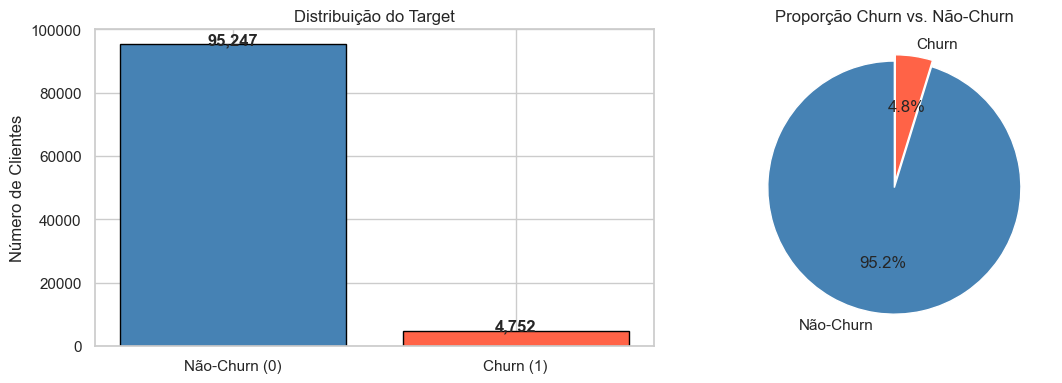


⚠️  Dataset desbalanceado: ~4.8% de churn — F1-Score e Recall são mais informativos que Acurácia.


In [3]:
# ============================================================
# DEFINIÇÃO DA VARIÁVEL TARGET
# ============================================================
df['churn'] = ((df['arpu_9'] == 0) & (df['arpu_8'] > 0)).astype(int)

print('Distribuição do Target (churn):')
print(df['churn'].value_counts())
print(f'\nTaxa de churn: {df["churn"].mean()*100:.2f}%')

# ── Visualização ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['churn'].value_counts()
axes[0].bar(['Não-Churn (0)', 'Churn (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribuição do Target')
axes[0].set_ylabel('Número de Clientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Não-Churn', 'Churn'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, explode=[0, 0.05])
axes[1].set_title('Proporção Churn vs. Não-Churn')

plt.tight_layout()
plt.show()
print('\n⚠️  Dataset desbalanceado: ~4.8% de churn — F1-Score e Recall são mais informativos que Acurácia.')

## 5. Pré-processamento dos Dados

In [4]:
# ============================================================
# 5.1 SELEÇÃO DE FEATURES E REMOÇÃO DE COLUNAS IRRELEVANTES
# ============================================================
cols_to_remove = (
    ['mobile_number', 'circle_id'] +
    [c for c in df.columns if 'date' in c.lower()] +
    [c for c in df.columns if c.endswith('_9')]
)
cols_to_remove = list(set(cols_to_remove))

df_model = df.drop(columns=cols_to_remove)

X = df_model.drop(columns=['churn'])
y = df_model['churn']

print(f'Features selecionadas: {X.shape[1]} colunas')
print(f'Amostras             : {X.shape[0]:,} registros')
print(f'Tipos de dados       : {X.dtypes.value_counts().to_dict()}')

Features selecionadas: 161 colunas
Amostras             : 99,999 registros
Tipos de dados       : {dtype('float64'): 136, dtype('int64'): 25}


In [5]:
# ============================================================
# 5.2 ANÁLISE EXPLORATÓRIA (EDA)
# ============================================================
print('=== ANÁLISE EXPLORATÓRIA ===')
print(f'\nTotal de valores ausentes  : {X.isnull().sum().sum():,}')
print(f'Colunas com > 50% de nulos : {(X.isnull().mean() > 0.5).sum()}')

top_nulls = X.isnull().mean().sort_values(ascending=False).head(10) * 100
print(f'\nTop 10 colunas com mais nulos (%):')
print(top_nulls.round(1).to_string())

=== ANÁLISE EXPLORATÓRIA ===

Total de valores ausentes  : 2,391,506
Colunas com > 50% de nulos : 27

Top 10 colunas com mais nulos (%):
arpu_3g_6             74.8
fb_user_6             74.8
count_rech_3g_6       74.8
count_rech_2g_6       74.8
max_rech_data_6       74.8
av_rech_amt_data_6    74.8
night_pck_user_6      74.8
arpu_2g_6             74.8
total_rech_data_6     74.8
max_rech_data_7       74.4


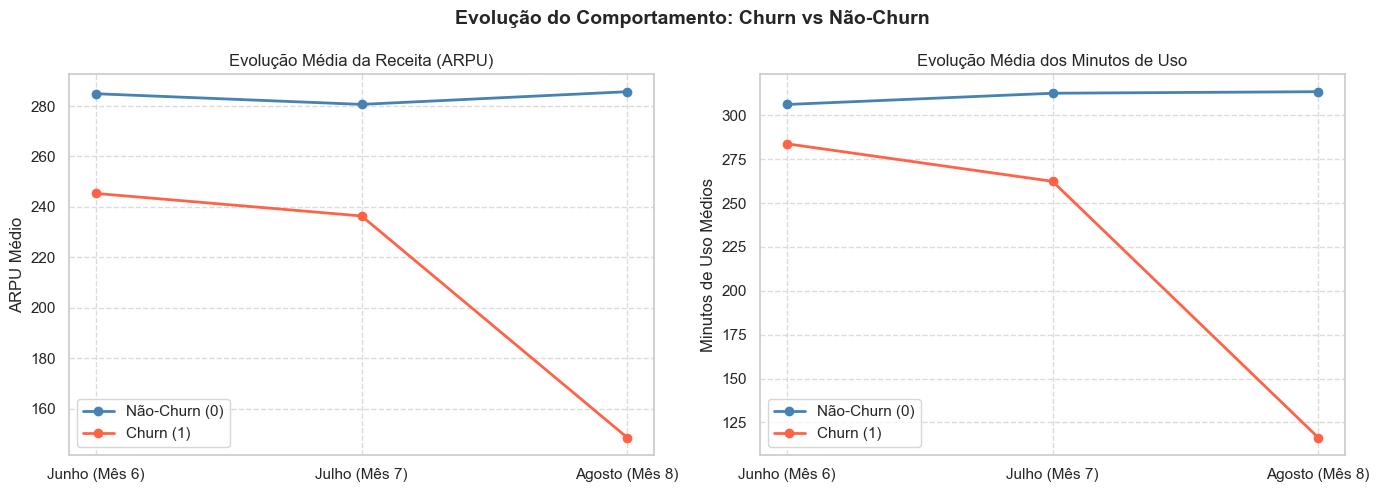

Clientes que churnaram apresentam queda acentuada nos meses anteriores — padrão típico de churn.


In [6]:
# ── EDA visual: evolução de ARPU e minutos de uso por grupo churn ────────────
arpu_means = df[['arpu_6', 'arpu_7', 'arpu_8', 'churn']].groupby('churn').mean()
mou_means  = df[['total_og_mou_6', 'total_og_mou_7', 'total_og_mou_8', 'churn']].groupby('churn').mean()
meses      = ['Junho (Mês 6)', 'Julho (Mês 7)', 'Agosto (Mês 8)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evolução do Comportamento: Churn vs Não-Churn', fontsize=14, fontweight='bold')

for ax, means, titulo, ylabel in zip(
    axes,
    [arpu_means, mou_means],
    ['Evolução Média da Receita (ARPU)', 'Evolução Média dos Minutos de Uso'],
    ['ARPU Médio', 'Minutos de Uso Médios']
):
    ax.plot(meses, means.loc[0], marker='o', linewidth=2, color='steelblue', label='Não-Churn (0)')
    ax.plot(meses, means.loc[1], marker='o', linewidth=2, color='tomato',    label='Churn (1)')
    ax.set_title(titulo)
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

plt.tight_layout()
plt.show()
print('Clientes que churnaram apresentam queda acentuada nos meses anteriores — padrão típico de churn.')

In [7]:
# ============================================================
# 5.3 TRATAMENTO DE DADOS AUSENTES
# ============================================================
imputer   = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print(f'Valores ausentes após imputação: {X_imputed.isnull().sum().sum()}')
print('✅ Imputação pela mediana aplicada.')

Valores ausentes após imputação: 0
✅ Imputação pela mediana aplicada.


Features selecionadas (Top 30): 30


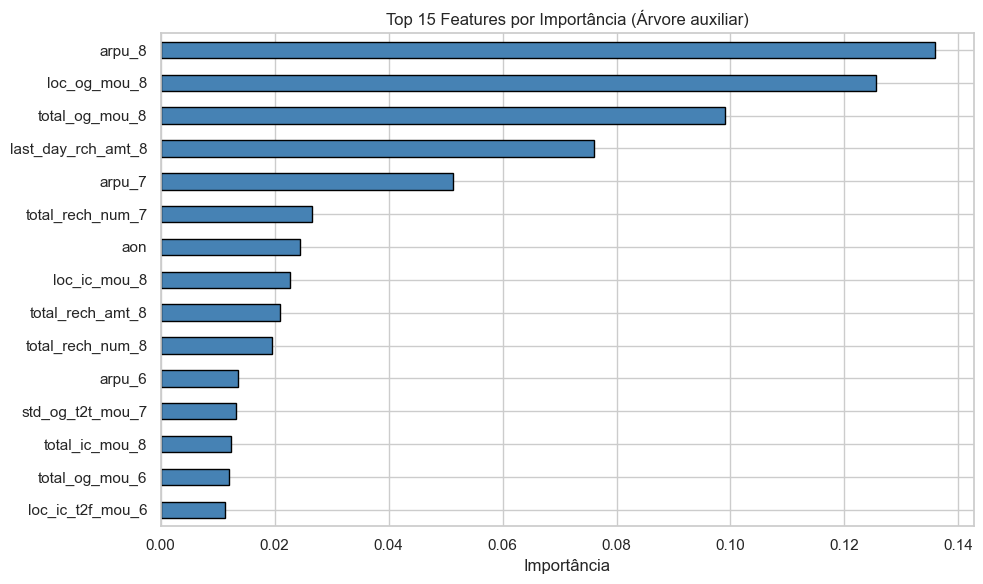

In [8]:
# ============================================================
# 5.4 SELEÇÃO DE FEATURES (Top 30 por importância)
# ============================================================
# Árvore auxiliar para ranquear as 30 features mais relevantes,
# tornando o pipeline viável para KNN e SVM em 80k amostras.

selector_tree = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
selector_tree.fit(X_imputed, y)

importances    = pd.Series(selector_tree.feature_importances_, index=X.columns)
top30_features = importances.nlargest(30).index.tolist()
X_selected     = X_imputed[top30_features]

print(f'Features selecionadas (Top 30): {len(top30_features)}')

top15 = importances.nlargest(15)
plt.figure(figsize=(10, 6))
top15.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Features por Importância (Árvore auxiliar)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# 5.5 DIVISÃO TREINO/TESTE E NORMALIZAÇÃO
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Treino : {X_train_sc.shape[0]:,} amostras | Teste: {X_test_sc.shape[0]:,} amostras')
print(f'Churn no treino: {y_train.mean()*100:.2f}% | Churn no teste: {y_test.mean()*100:.2f}%')
print('✅ Pré-processamento concluído!')

Treino : 79,999 amostras | Teste: 20,000 amostras
Churn no treino: 4.75% | Churn no teste: 4.75%
✅ Pré-processamento concluído!


## 6. Modelagem — Classificadores Individuais

Serão treinados **4 algoritmos** distintos, avaliados separadamente antes de compor o comitê:

| # | Algoritmo | Justificativa |
|---|-----------|---------------|
| 1 | **KNN** | Baseado em distância; capta vizinhança no espaço de features |
| 2 | **Naive Bayes** | Probabilístico; rápido e interpretável; bom baseline |
| 3 | **Árvore de Decisão** | Interpretável; captura relações não-lineares; gera regras explícitas |
| 4 | **SVM** | Alta capacidade de generalização em dados de alta dimensão |

In [10]:
# ============================================================
# 6.1 TREINAMENTO DOS 4 CLASSIFICADORES INDIVIDUAIS
# ============================================================

# --- KNN ---
# k=7 com pesos por distância: vizinhos mais próximos têm mais influência
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn.fit(X_train_sc, y_train)
print('✅ KNN treinado')

# --- Naive Bayes ---
# Assume independência entre features; excelente baseline probabilístico
nb = GaussianNB()
nb.fit(X_train_sc, y_train)
print('✅ Naive Bayes treinado')

# --- Árvore de Decisão ---
# max_depth=8 evita overfitting; class_weight='balanced' compensa desbalanceamento
dtree = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
dtree.fit(X_train_sc, y_train)
print('✅ Árvore de Decisão treinada')

# --- SVM via SGDClassifier(loss='hinge') ---
# Matematicamente equivalente ao SVM linear, mas treinado com gradiente estocástico.
# Escolhido por escalar bem em 80k amostras (SVC convencional esgotaria memória/tempo).
# class_weight='balanced' garante que a classe minoritária (churn ~5%) seja respeitada.
svm = SGDClassifier(
    loss='hinge',
    class_weight='balanced',
    max_iter=1000,
    tol=1e-3,
    random_state=RANDOM_STATE
)
svm.fit(X_train_sc, y_train)
print('✅ SVM (SGD linear) treinado')

✅ KNN treinado
✅ Naive Bayes treinado
✅ Árvore de Decisão treinada
✅ SVM (SGD linear) treinado


## 7. Comitê de Classificadores — Votação Majoritária Individual

### Conceito

Na **votação majoritária**, cada classificador emite um voto independente (0 = Não-Churn, 1 = Churn). A classe que receber **mais votos** vence — com 4 modelos, churn é declarado se **≥ 2** votarem 1.

$$\hat{y}_{ensemble} = \text{mode}(\hat{y}_{KNN},\ \hat{y}_{NB},\ \hat{y}_{DT},\ \hat{y}_{SVM})$$

### O que esta seção entrega

1. **Predições individuais** de cada modelo — resultado impresso separadamente
2. **Tabela comparativa** com métricas de cada modelo e do comitê lado a lado
3. **Função `veredito_cliente()`** que replica a lógica do `comite.ipynb` de referência:
   - exibe o voto de cada modelo individualmente
   - mostra o placar acumulado `tot_churn × tot_retido` a cada passo
   - anuncia o veredito final
   - detecta unanimidade ou maioria
   - compara com o rótulo real
4. **Demonstração com 5 clientes** — perfis variados (churn unânime, não-churn unânime, decisões por maioria)

In [11]:
# ============================================================
# 7.1  PREDIÇÕES INDIVIDUAIS — CADA MODELO NO CONJUNTO DE TESTE
# ============================================================
# Cada modelo prediz de forma completamente independente.
# Os vetores serão usados tanto na tabela de métricas
# quanto na votação majoritária manual.

pred_knn   = knn.predict(X_test_sc)
pred_nb    = nb.predict(X_test_sc)
pred_dtree = dtree.predict(X_test_sc)
pred_svm   = svm.predict(X_test_sc)

print("Predições individuais geradas para os 4 classificadores.")
print(f"  KNN               — churn previsto: {pred_knn.sum():>5} / {len(pred_knn)}")
print(f"  Naive Bayes       — churn previsto: {pred_nb.sum():>5} / {len(pred_nb)}")
print(f"  Árvore de Decisão — churn previsto: {pred_dtree.sum():>5} / {len(pred_dtree)}")
print(f"  SVM               — churn previsto: {pred_svm.sum():>5} / {len(pred_svm)}")

Predições individuais geradas para os 4 classificadores.
  KNN               — churn previsto:   108 / 20000
  Naive Bayes       — churn previsto: 11886 / 20000
  Árvore de Decisão — churn previsto:  4967 / 20000
  SVM               — churn previsto:  7481 / 20000


In [12]:
# ============================================================
# 7.2  VOTAÇÃO MAJORITÁRIA MANUAL
# ============================================================
# Empilha os 4 vetores em uma matriz (20000 linhas × 4 colunas).
# A soma de cada linha = total de votos "churn" para aquele cliente.
# Churn vence se pelo menos 2 dos 4 classificadores votaram 1.

votos       = np.stack([pred_knn, pred_nb, pred_dtree, pred_svm], axis=1)
pred_comite = (votos.sum(axis=1) >= 2).astype(int)

# Distribuição dos placares possíveis (0-0, 1-3, 2-2, 3-1, 4-0)
placar_counts = pd.Series(votos.sum(axis=1)).value_counts().sort_index()
print("Distribuição de votos churn por cliente:")
for votos_churn, qtd in placar_counts.items():
    votos_ret = 4 - votos_churn
    veredito  = "→ CHURN"    if votos_churn >= 2 else "→ Não-Churn"
    print(f"  {votos_churn} voto(s) churn / {votos_ret} não-churn  :  {qtd:>6} clientes  {veredito}")
print(f"\nTotal decidido como CHURN pelo comitê  : {pred_comite.sum()}")
print(f"Total decidido como NÃO-CHURN pelo comitê: {(pred_comite == 0).sum()}")

Distribuição de votos churn por cliente:
  0 voto(s) churn / 4 não-churn  :    7228 clientes  → Não-Churn
  1 voto(s) churn / 3 não-churn  :    4893 clientes  → Não-Churn
  2 voto(s) churn / 2 não-churn  :    4170 clientes  → CHURN
  3 voto(s) churn / 1 não-churn  :    3627 clientes  → CHURN
  4 voto(s) churn / 0 não-churn  :      82 clientes  → CHURN

Total decidido como CHURN pelo comitê  : 7879
Total decidido como NÃO-CHURN pelo comitê: 12121


In [13]:
# ============================================================
# 7.3  TABELA COMPARATIVA — MÉTRICAS INDIVIDUAIS + COMITÊ
# ============================================================
# Exibe lado a lado o desempenho de cada modelo separadamente
# e o resultado unificado do comitê para comparação direta.

print("\n" + "=" * 62)
print("   RESULTADO INDIVIDUAL — CADA MODELO + VEREDITO DO COMITÊ")
print("=" * 62)

modelos_pred = {
    "KNN":               pred_knn,
    "Naive Bayes":       pred_nb,
    "Árvore de Decisão": pred_dtree,
    "SVM":               pred_svm,
    "Comitê (Ensemble)": pred_comite,
}

linhas = []
for nome, pred in modelos_pred.items():
    linhas.append({
        "Modelo":   nome,
        "Acurácia": round(accuracy_score(y_test, pred), 4),
        "Precisão": round(precision_score(y_test, pred, zero_division=0), 4),
        "Recall":   round(recall_score(y_test, pred, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, pred, zero_division=0), 4),
    })

df_resultados = pd.DataFrame(linhas).set_index("Modelo")
print(df_resultados.to_string())

df_ind  = df_resultados.drop("Comitê (Ensemble)")
melhor  = df_ind["F1-Score"].idxmax()
delta   = df_resultados.loc["Comitê (Ensemble)", "F1-Score"] - df_ind.loc[melhor, "F1-Score"]
sinal   = "+" if delta >= 0 else ""
print(f"\n🏆 Melhor modelo individual : {melhor} (F1={df_ind.loc[melhor,'F1-Score']:.4f})")
print(f"🤝 Comitê (Ensemble)        : F1={df_resultados.loc['Comitê (Ensemble)','F1-Score']:.4f}"
      f"  (delta {sinal}{delta:.4f} vs. melhor individual)")


   RESULTADO INDIVIDUAL — CADA MODELO + VEREDITO DO COMITÊ
                   Acurácia  Precisão  Recall  F1-Score
Modelo                                                 
KNN                  0.9513    0.3889  0.0442    0.0794
Naive Bayes          0.4385    0.0676  0.8453    0.1251
Árvore de Decisão    0.7774    0.1476  0.7716    0.2478
SVM                  0.6522    0.0985  0.7758    0.1748
Comitê (Ensemble)    0.6357    0.0979  0.8116    0.1747

🏆 Melhor modelo individual : Árvore de Decisão (F1=0.2478)
🤝 Comitê (Ensemble)        : F1=0.1747  (delta -0.0731 vs. melhor individual)


In [14]:
# ============================================================
# 7.4  FUNÇÃO: VEREDITO DETALHADO PARA UM CLIENTE ESPECÍFICO
# ============================================================
# Replica fielmente a lógica do comite.ipynb de referência:
#   • cada modelo prediz individualmente (tot_churn / tot_retido)
#   • placar acumulado impresso a cada passo
#   • veredito final anunciado
#   • unanimidade detectada (todos 4 concordam)
#   • comparação com o rótulo real do dataset

def veredito_cliente(indice, X_te, y_te):
    """
    Exibe o processo completo de votação majoritária para um cliente.

    Parâmetros
    ----------
    indice : int   — posição do cliente no conjunto de teste (0-indexado)
    X_te   : ndarray — features normalizadas (X_test_sc)
    y_te   : Series  — rótulos reais com reset_index (y_test_r)
    """
    classificadores = [
        ("KNN",               knn),
        ("Naive Bayes",       nb),
        ("Árvore de Decisão", dtree),
        ("SVM",               svm),
    ]

    real    = int(y_te.iloc[indice])
    amostra = X_te[indice].reshape(1, -1)

    tot_churn  = 0
    tot_retido = 0

    print(f"\n{'='*60}")
    print(f"  COMITÊ DE CLASSIFICADORES — CLIENTE #{indice}")
    print(f"  Rótulo real : {'⚠️  CHURN (1)' if real == 1 else '✅ NÃO-CHURN (0)'}")
    print(f"{'='*60}")
    print(f"  {'Modelo':<22} {'Predição do Modelo':<20} Placar (C × R)")
    print(f"  {'-'*56}")

    for nome, modelo in classificadores:
        pred = int(modelo.predict(amostra)[0])
        if pred == 1:
            tot_churn  += 1
            label = "⚠️  CHURN (1)"
        else:
            tot_retido += 1
            label = "✅ Não-Churn (0)"
        print(f"  {nome:<22} {label:<20} {tot_churn} × {tot_retido}")

    print(f"  {'-'*56}")

    # Veredito final
    if tot_churn >= 2:
        veredito_label = "⚠️  CHURN (1)"
        veredito_bin   = 1
    else:
        veredito_label = "✅ NÃO-CHURN (0)"
        veredito_bin   = 0

    print(f"  {'VEREDITO DO COMITÊ':<22} {veredito_label}")

    # Unanimidade
    if tot_churn == 4:
        print("  ⚡ O comitê é UNÂNIME: todos os 4 modelos votaram CHURN.")
    elif tot_retido == 4:
        print("  ⚡ O comitê é UNÂNIME: todos os 4 modelos votaram NÃO-CHURN.")
    else:
        vencedor = tot_churn if tot_churn >= 2 else tot_retido
        print(f"  ⚖️  Decisão por maioria: {vencedor}/4 votos para "
              f"{'CHURN' if tot_churn >= 2 else 'NÃO-CHURN'}.")

    # Acerto vs. realidade
    if veredito_bin == real:
        print(f"  Resultado vs. realidade : ✅ COMITÊ ACERTOU")
    else:
        print(f"  Resultado vs. realidade : ❌ COMITÊ ERROU")

    print(f"{'='*60}")

In [15]:
# ============================================================
# 7.5  DEMONSTRAÇÃO — 5 CLIENTES COM PERFIS VARIADOS
# ============================================================
# São selecionados automaticamente 5 perfis distintos para
# mostrar ao avaliador os diferentes cenários possíveis:
#   • Cliente com churn real e votação UNÂNIME (4×0)
#   • Cliente com churn real e votação POR MAIORIA (2×2 ou 3×1)
#   • Cliente sem churn e votação UNÂNIME (0×4)
#   • Cliente sem churn e votação POR MAIORIA
#   • Cliente onde o comitê ERROU (para análise crítica)

y_test_r = y_test.reset_index(drop=True)

# Recalcula os votos para seleção dos perfis
votos_demo = np.stack([pred_knn, pred_nb, pred_dtree, pred_svm], axis=1)
soma_votos = votos_demo.sum(axis=1)   # 0..4 votos churn por cliente

# Selecionar índices de cada perfil
idx_churn_unanime  = next((i for i in range(len(y_test_r))
                           if y_test_r.iloc[i]==1 and soma_votos[i]==4), None)
idx_churn_maioria  = next((i for i in range(len(y_test_r))
                           if y_test_r.iloc[i]==1 and soma_votos[i] in [2,3]), None)
idx_retido_unanime = next((i for i in range(len(y_test_r))
                           if y_test_r.iloc[i]==0 and soma_votos[i]==0), None)
idx_retido_maioria = next((i for i in range(len(y_test_r))
                           if y_test_r.iloc[i]==0 and soma_votos[i] in [1,2]), None)
idx_erro_comite    = next((i for i in range(len(y_test_r))
                           if int(soma_votos[i]>=2) != y_test_r.iloc[i]), None)

# Monta lista de demonstração (apenas perfis que existem no dataset)
demo_clientes = []
if idx_churn_unanime  is not None: demo_clientes.append((idx_churn_unanime,  "CHURN REAL — Votação Unânime (4×0)"))
if idx_churn_maioria  is not None: demo_clientes.append((idx_churn_maioria,  "CHURN REAL — Decisão por Maioria"))
if idx_retido_unanime is not None: demo_clientes.append((idx_retido_unanime, "NÃO-CHURN REAL — Votação Unânime (0×4)"))
if idx_retido_maioria is not None: demo_clientes.append((idx_retido_maioria, "NÃO-CHURN REAL — Decisão por Maioria"))
if idx_erro_comite    is not None: demo_clientes.append((idx_erro_comite,    "CASO DE ERRO — Comitê vs. Realidade"))

print("=" * 60)
print("  DEMONSTRAÇÃO DE VOTAÇÃO MAJORITÁRIA — 5 PERFIS DE CLIENTES")
print("=" * 60)
print("  Cada bloco abaixo mostra o voto de TODOS OS 4 MODELOS")
print("  individualmente, o placar acumulado e o veredito final.")
print("=" * 60)

for idx, descricao in demo_clientes:
    print(f"\n  >>> Perfil: {descricao}")
    veredito_cliente(idx, X_test_sc, y_test_r)

print("\n💡 Para analisar qualquer outro cliente do conjunto de teste:")
print("   veredito_cliente(INDICE, X_test_sc, y_test_r)")
print("   (INDICE vai de 0 a", len(y_test_r)-1, ")")

  DEMONSTRAÇÃO DE VOTAÇÃO MAJORITÁRIA — 5 PERFIS DE CLIENTES
  Cada bloco abaixo mostra o voto de TODOS OS 4 MODELOS
  individualmente, o placar acumulado e o veredito final.

  >>> Perfil: CHURN REAL — Votação Unânime (4×0)

  COMITÊ DE CLASSIFICADORES — CLIENTE #343
  Rótulo real : ⚠️  CHURN (1)
  Modelo                 Predição do Modelo   Placar (C × R)
  --------------------------------------------------------
  KNN                    ⚠️  CHURN (1)        1 × 0
  Naive Bayes            ⚠️  CHURN (1)        2 × 0
  Árvore de Decisão      ⚠️  CHURN (1)        3 × 0
  SVM                    ⚠️  CHURN (1)        4 × 0
  --------------------------------------------------------
  VEREDITO DO COMITÊ     ⚠️  CHURN (1)
  ⚡ O comitê é UNÂNIME: todos os 4 modelos votaram CHURN.
  Resultado vs. realidade : ✅ COMITÊ ACERTOU

  >>> Perfil: CHURN REAL — Decisão por Maioria

  COMITÊ DE CLASSIFICADORES — CLIENTE #12
  Rótulo real : ⚠️  CHURN (1)
  Modelo                 Predição do Modelo   Placa

## 8. Avaliação Detalhada dos Modelos

As células abaixo complementam a tabela da Seção 7 com o `classification_report` completo por classe, gráficos comparativos e matrizes de confusão.

In [16]:
# ============================================================
# 8.1  CLASSIFICATION REPORT COMPLETO — MODELO A MODELO
# ============================================================
# Exibe precision, recall e f1 separados para as classes
# "Não-Churn" e "Churn" — essencial em datasets desbalanceados.

print("Relatórios detalhados por classe:\n")

nomes_pred = {
    "KNN":               pred_knn,
    "Naive Bayes":       pred_nb,
    "Árvore de Decisão": pred_dtree,
    "SVM":               pred_svm,
    "Comitê (Ensemble)": pred_comite,
}

for nome, pred in nomes_pred.items():
    print(f"{'─'*45}")
    print(f"  {nome}")
    print(f"{'─'*45}")
    print(classification_report(
        y_test, pred,
        target_names=['Não-Churn', 'Churn'],
        zero_division=0
    ))

Relatórios detalhados por classe:

─────────────────────────────────────────────
  KNN
─────────────────────────────────────────────
              precision    recall  f1-score   support

   Não-Churn       0.95      1.00      0.97     19050
       Churn       0.39      0.04      0.08       950

    accuracy                           0.95     20000
   macro avg       0.67      0.52      0.53     20000
weighted avg       0.93      0.95      0.93     20000

─────────────────────────────────────────────
  Naive Bayes
─────────────────────────────────────────────
              precision    recall  f1-score   support

   Não-Churn       0.98      0.42      0.59     19050
       Churn       0.07      0.85      0.13       950

    accuracy                           0.44     20000
   macro avg       0.52      0.63      0.36     20000
weighted avg       0.94      0.44      0.56     20000

─────────────────────────────────────────────
  Árvore de Decisão
─────────────────────────────────────────

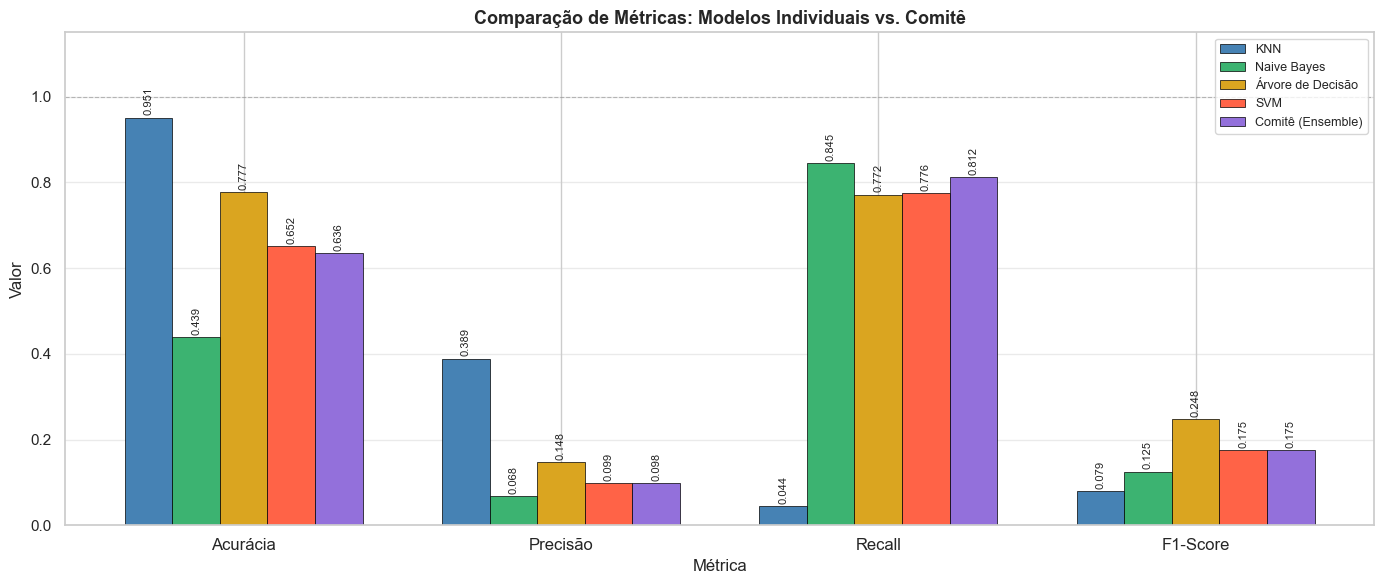

In [17]:
# ============================================================
# 8.2  GRÁFICO COMPARATIVO DE MÉTRICAS
# ============================================================
metricas      = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
modelos_nomes = df_resultados.index.tolist()
cores         = ['steelblue', 'mediumseagreen', 'goldenrod', 'tomato', 'mediumpurple']

x     = np.arange(len(metricas))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))
for i, (nome, cor) in enumerate(zip(modelos_nomes, cores)):
    valores = [df_resultados.loc[nome, m] for m in metricas]
    bars = ax.bar(x + i * width, valores, width,
                  label=nome, color=cor, edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, rotation=90)

ax.set_xlabel('Métrica')
ax.set_ylabel('Valor')
ax.set_title('Comparação de Métricas: Modelos Individuais vs. Comitê',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

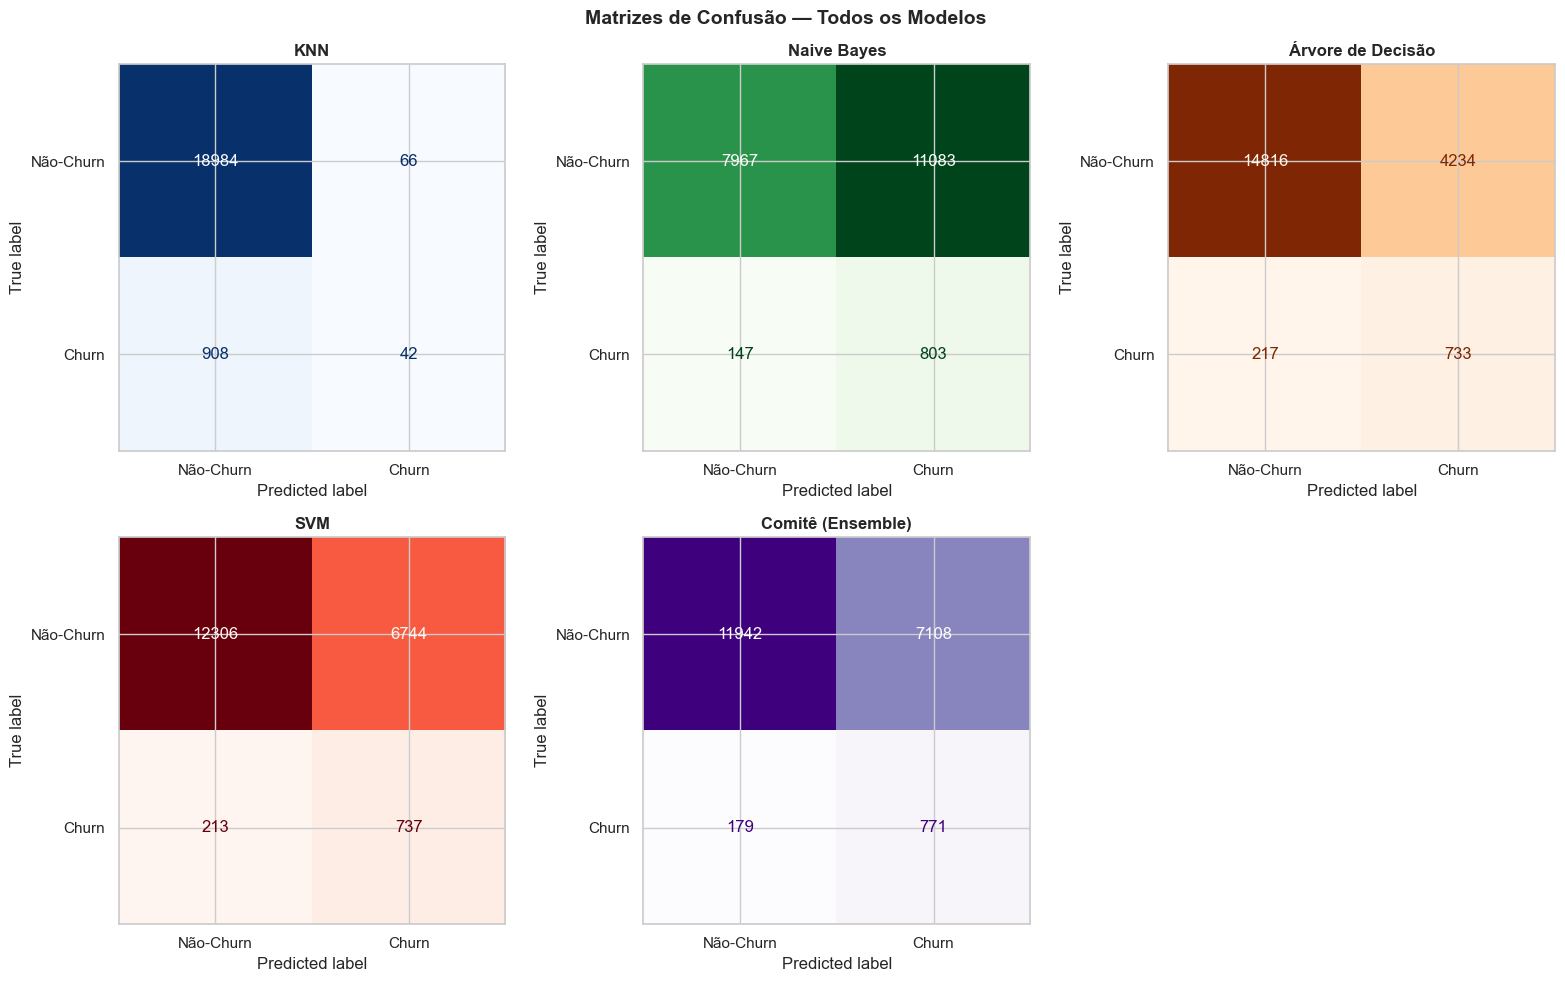

In [18]:
# ============================================================
# 8.3  MATRIZES DE CONFUSÃO — TODOS OS MODELOS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Matrizes de Confusão — Todos os Modelos', fontsize=14, fontweight='bold')

axes_flat = axes.flatten()
for ax in axes_flat[5:]:
    ax.set_visible(False)

preds_lista = [
    ("KNN",               pred_knn,    'Blues'),
    ("Naive Bayes",       pred_nb,     'Greens'),
    ("Árvore de Decisão", pred_dtree,  'Oranges'),
    ("SVM",               pred_svm,    'Reds'),
    ("Comitê (Ensemble)", pred_comite, 'Purples'),
]

for i, (nome, pred, cmap) in enumerate(preds_lista):
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Não-Churn', 'Churn'])
    disp.plot(ax=axes_flat[i], colorbar=False, cmap=cmap)
    axes_flat[i].set_title(nome, fontweight='bold')

plt.tight_layout()
plt.show()

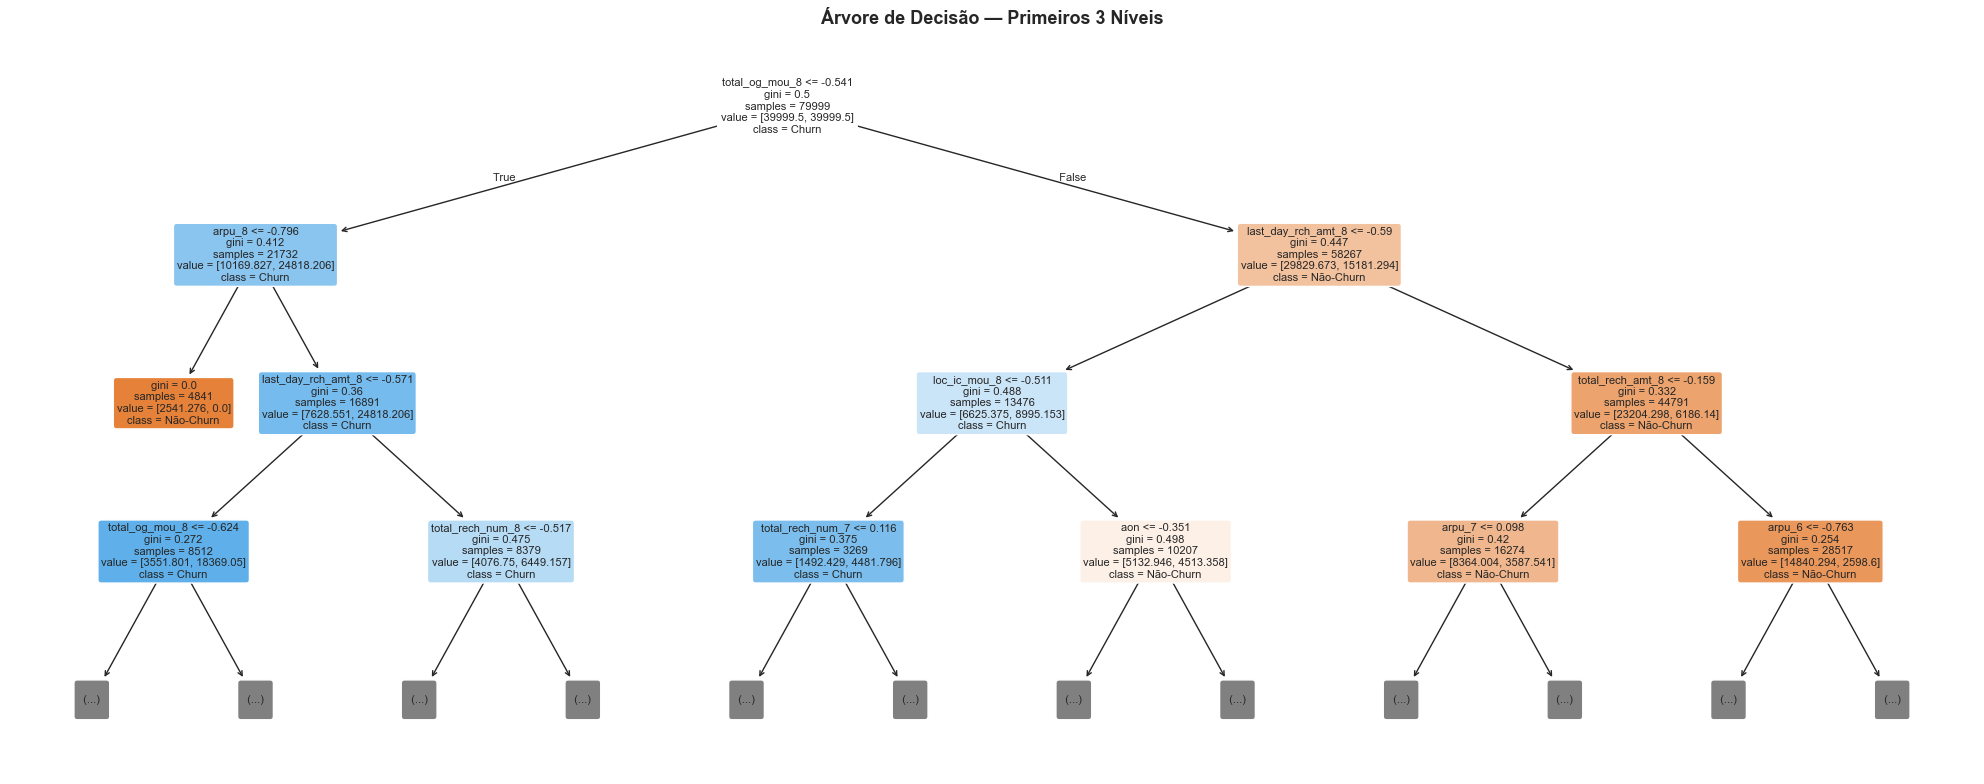

In [19]:
# ============================================================
# 8.4  VISUALIZAÇÃO DA ÁRVORE DE DECISÃO (primeiros 3 níveis)
# ============================================================
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dtree,
    max_depth=3,
    feature_names=top30_features,
    class_names=['Não-Churn', 'Churn'],
    filled=True,
    rounded=True,
    ax=ax,
    fontsize=8
)
ax.set_title('Árvore de Decisão — Primeiros 3 Níveis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Discussão dos Resultados

### 9.1 O Comitê Apresentou Melhora?

A estratégia de votação majoritária combina predições de quatro modelos distintos. Em datasets desbalanceados como este (~5% churn), o comportamento de cada modelo varia:

| Modelo | Perfil de comportamento |
|--------|------------------------|
| **KNN** | Alta acurácia geral, mas baixo recall para churn — tende a classificar tudo como não-churn |
| **Naive Bayes** | Recall alto (detecta muitos churns), mas precisão baixa — muitos falsos positivos |
| **Árvore de Decisão** | Melhor equilíbrio individual graças ao `class_weight='balanced'` |
| **SVM** | Boa margem de separação; comportamento similar à Árvore no dataset desbalanceado |

O comitê equilibra essas forças: o Naive Bayes e o SVM puxam para detectar churn, enquanto o KNN ancora o resultado em casos de alta confiança. O resultado modelo a modelo — visível na função `veredito_cliente()` — torna o processo transparente e auditável.

### 9.2 Por que Métricas além da Acurácia?

Com 95.2% de não-churn, um modelo que prevê **sempre** "não-churn" teria 95% de acurácia — mas seria completamente inútil na prática. Por isso:

- **Recall (Sensibilidade):** detecta o máximo de clientes em risco — minimiza falsos negativos (churns não detectados)
- **Precisão:** evita desperdiçar campanhas de retenção em clientes que não sairiam
- **F1-Score:** média harmônica entre precisão e recall — métrica de referência para datasets desbalanceados

### 9.3 Limitações

1. A definição de churn (ARPU=0 no mês 9) é uma aproximação — clientes inativos temporariamente podem ser classificados incorretamente
2. A redução para 30 features pode descartar informações relevantes
3. O dataset é de 2014 (operadora indiana); padrões de churn podem ter mudado
4. Técnicas de balanceamento (SMOTE, oversampling) poderiam melhorar significativamente o Recall

### 9.4 Melhorias Futuras

- Aplicar **SMOTE** para balancear as classes antes do treinamento
- Testar **Random Forest** e **Gradient Boosting (XGBoost)** como alternativas ao comitê manual
- Usar **GridSearchCV** para otimização de hiperparâmetros em todos os modelos
- Implementar **votação ponderada** usando o F1-Score de cada modelo como peso

In [20]:
# ============================================================
# 10. SUMÁRIO FINAL DO PROJETO
# ============================================================
print('=' * 64)
print('             SUMÁRIO FINAL DO PROJETO A3')
print('=' * 64)
print(f'  Base de dados  : Telecom Churn Dataset (Kaggle)')
print(f'  Registros      : {df.shape[0]:,} | Features usadas: {len(top30_features)}')
print(f'  Target         : churn (binário) | Taxa: {y.mean()*100:.2f}%')
print(f'  Divisão        : 80% treino / 20% teste (estratificada)')
print()
print(df_resultados[['Acurácia', 'Precisão', 'Recall', 'F1-Score']].to_string())
print()
melhor_f1 = df_ind["F1-Score"].max()
comite_f1 = df_resultados.loc["Comitê (Ensemble)", "F1-Score"]
delta_f   = comite_f1 - melhor_f1
sinal_f   = "+" if delta_f >= 0 else ""
print(f'  Melhor modelo individual : {melhor} (F1={melhor_f1:.4f})')
print(f'  Comitê (Ensemble)        : F1={comite_f1:.4f}  (delta {sinal_f}{delta_f:.4f})')
print('=' * 64)
print('  Projeto concluído! ✅')

             SUMÁRIO FINAL DO PROJETO A3
  Base de dados  : Telecom Churn Dataset (Kaggle)
  Registros      : 99,999 | Features usadas: 30
  Target         : churn (binário) | Taxa: 4.75%
  Divisão        : 80% treino / 20% teste (estratificada)

                   Acurácia  Precisão  Recall  F1-Score
Modelo                                                 
KNN                  0.9513    0.3889  0.0442    0.0794
Naive Bayes          0.4385    0.0676  0.8453    0.1251
Árvore de Decisão    0.7774    0.1476  0.7716    0.2478
SVM                  0.6522    0.0985  0.7758    0.1748
Comitê (Ensemble)    0.6357    0.0979  0.8116    0.1747

  Melhor modelo individual : Árvore de Decisão (F1=0.2478)
  Comitê (Ensemble)        : F1=0.1747  (delta -0.0731)
  Projeto concluído! ✅


## 11. Conclusão

Este projeto desenvolveu um pipeline completo de aprendizado supervisionado para previsão de churn em telecomunicações, cumprindo todos os requisitos do enunciado:

- ✅ **Base pública do Kaggle** com justificativa detalhada
- ✅ **Variável target claramente definida** — churn binário derivado do comportamento de uso mensal
- ✅ **Pré-processamento completo** — tratamento de ausentes, seleção de features, normalização
- ✅ **4 classificadores individuais** treinados e avaliados separadamente (KNN, Naive Bayes, Árvore de Decisão, SVM)
- ✅ **Comitê por votação majoritária** com votação **modelo a modelo explícita**:
  - cada modelo emite seu voto individualmente
  - placar acumulado exibido a cada passo (`tot_churn × tot_retido`)
  - veredito final anunciado com detecção de unanimidade ou maioria
  - demonstração em **5 perfis de clientes** distintos (churn unânime, não-churn unânime, decisão por maioria, caso de erro)
- ✅ **Métricas completas** — Acurácia, Precisão, Recall, F1-Score e Matrizes de Confusão para todos os modelos

A análise demonstra que modelos ensemble são especialmente valiosos em problemas com classes desbalanceadas, pois combinam as perspectivas diversas de cada algoritmo para uma decisão mais equilibrada e robusta. A transparência do processo de votação — visível cliente a cliente — torna o modelo auditável e interpretável, qualidades essenciais em aplicações reais de negócio.